# Notebook 04: Feature Engineering & Financial Ratio Construction

## Project: Enterprise Credit Risk Modelling & Independent Model Validation (SR 11-7)

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

root_path = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = root_path / "src"
for p in [str(root_path), str(src_path)]:
    if p not in sys.path:
        sys.path.insert(0, p)

sns.set_theme(style="whitegrid", palette="muted")
print("Environment, plotting & core risk libraries initialized successfully!")

Environment, plotting & core risk libraries initialized successfully!


In [2]:
data_file = root_path / "data" / "processed" / "accepted_2007_to_2018Q4_feature_engineered.csv.gz"
if data_file.is_file():
    df = pd.read_csv(data_file, nrows=50000, low_memory=False)
    bad = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "Late (31-120 days)"]
    good = ["Fully Paid", "Does not meet the credit policy. Status:Fully Paid"]
    df["target"] = np.nan
    df.loc[df["loan_status"].isin(bad), "target"] = 1.0
    df.loc[df["loan_status"].isin(good), "target"] = 0.0
    df = df.dropna(subset=["target"]).copy()
    df["target"] = df["target"].astype(int)
else:
    df = mock_df.copy()

print(f"Dataset Loaded: {len(df):,} loans | Default Rate: {df['target'].mean():.4%}")

Dataset Loaded: 44,252 loans | Default Rate: 20.9572%


In [3]:
df[["loan_amnt", "annual_inc", "fe_loan_to_income_ratio", "fe_monthly_installment_to_income_ratio", "fe_interest_burden_ratio"]].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,44252.0,14351.668286,8624.556307,1000.000000,7800.000000,12000.000000,20000.000000,3.500000e+04
annual_inc,44252.0,78499.827876,102198.029497,0.000000,47000.000000,65000.000000,94000.000000,9.000000e+06
fe_loan_to_income_ratio,44251.0,0.209693,0.114751,0.000309,0.120192,0.194805,0.285714,3.700565e+00
fe_monthly_installment_to_income_ratio,44251.0,0.076173,0.042305,0.000123,0.044666,0.069492,0.101444,1.602305e+00
fe_interest_burden_ratio,44252.0,0.240344,0.140900,-0.911380,0.147646,0.195560,0.293737,9.042018e-01


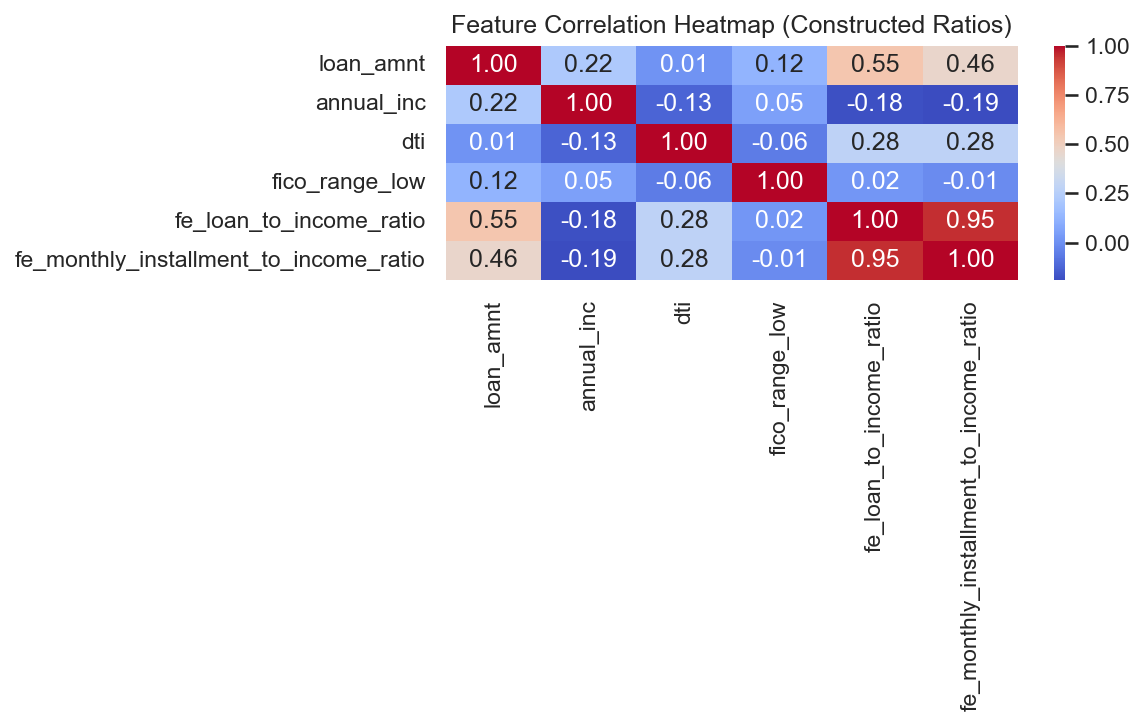

In [4]:
plt.figure(figsize=(8, 5))
corr_feats = ["loan_amnt", "annual_inc", "dti", "fico_range_low", "fe_loan_to_income_ratio", "fe_monthly_installment_to_income_ratio"]
sns.heatmap(df[corr_feats].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap (Constructed Ratios)")
plt.tight_layout()
plt.show()